# Data Understanding Phase - Vital Products Dataset
## Avatar Project - TDSP Methodology

**Project Context:** Intelligent conversational avatar for pharmaceutical and medical sectors

**Dataset:** vital_products.csv - Product catalog from Vital pharmaceutical company

**Objective:** Understand the structure, content, and quality of the product data to support:
- Training mode (simulation scenarios)
- Commercial mode (automated presentations)
- CRM integration and analytics

---
## 1. Load Data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('vital_products.csv', encoding='utf-8-sig')

print(f"Dataset loaded: {df.shape[0]} products, {df.shape[1]} columns")

Dataset loaded: 215 products, 8 columns


---
## 2. First Look at Data

In [7]:
# Show first 5 rows
df.head()

,name,url,image_url,categories,indications,forme,infos_produit,classe
0,LV Vitamine A,https://vital.com.tn/products/vitamine-a-2/,https://vital.com.tn/wp-content/uploads/2020/0...,"Acné, Peau",– Engelure – Réduit l’apparition des rides – T...,Créme,NaN,complément alimentaire
1,LV Fersang junior,https://vital.com.tn/products/lv-fersang-junior/,https://vital.com.tn/wp-content/uploads/2022/0...,"Anémie, Carence en Fer",– Traitement de l’anémie chez l’enfant à part...,Sirop,Flacon de 150 ml,Complément alimentaire
2,Hydra eau micellaire,https://vital.com.tn/products/hydra-eau-micell...,https://vital.com.tn/wp-content/uploads/2022/0...,Peau,– Nettoyante – Démaquillante – Purifiante –...,NaN,Peau normale,NaN
3,Alcool de menthe,https://vital.com.tn/products/alcool-de-menthe...,https://vital.com.tn/wp-content/uploads/2018/0...,"Troubles de la digestion, Ballonnement et gaz",Garder hors de la portée des enfants,Liquide,Flacon de 37 ml,Produit de soin
4,Vitonic Tonus,https://vital.com.tn/products/vitonic-tonus-2-2/,https://vital.com.tn/wp-content/uploads/2017/0...,Revitalisant,Aucune,Gélule,1 boite de 30 gélules,Complément alimentaire


In [9]:
# Show dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           215 non-null    object
 1   url            215 non-null    object
 2   image_url      215 non-null    object
 3   categories     215 non-null    object
 4   indications    214 non-null    object
 5   forme          198 non-null    object
 6   infos_produit  181 non-null    object
 7   classe         183 non-null    object
dtypes: object(8)
memory usage: 13.6+ KB


In [11]:
# Show column names
print("Columns:")
for col in df.columns:
    print(f"  - {col}")

Columns:
  - name
  - url
  - image_url
  - categories
  - indications
  - forme
  - infos_produit
  - classe


---
## 3. Check Data Quality

In [14]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing Values:
name              0
url               0
image_url         0
categories        0
indications       1
forme            17
infos_produit    34
classe           32
dtype: int64

Missing percentage:
name              0.0
url               0.0
image_url         0.0
categories        0.0
indications       0.5
forme             7.9
infos_produit    15.8
classe           14.9
dtype: float64


In [16]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate product names: {df['name'].duplicated().sum()}")

Duplicate rows: 0
Duplicate product names: 4


---
## 4. Analyze Product Forms

In [19]:
# Count product forms
print("Product Forms:")
print(df['forme'].value_counts())

Product Forms:
forme
Gélule                                     49
Sirop                                      24
Gélules                                    15
Savon                                      12
Crème                                      10
Gel                                         9
Gummies                                     8
Capsule                                     7
Sachets                                     6
Solution buvable                            6
Liquide                                     6
Huile                                       5
Spray                                       4
Lait                                        3
Pommade                                     3
Lotion                                      2
Crème pour usage externe                    2
Flacon (250 ml)                             2
Capsules moles et gélules                   2
sirop                                       2
Shampooing                                  2
Créme        

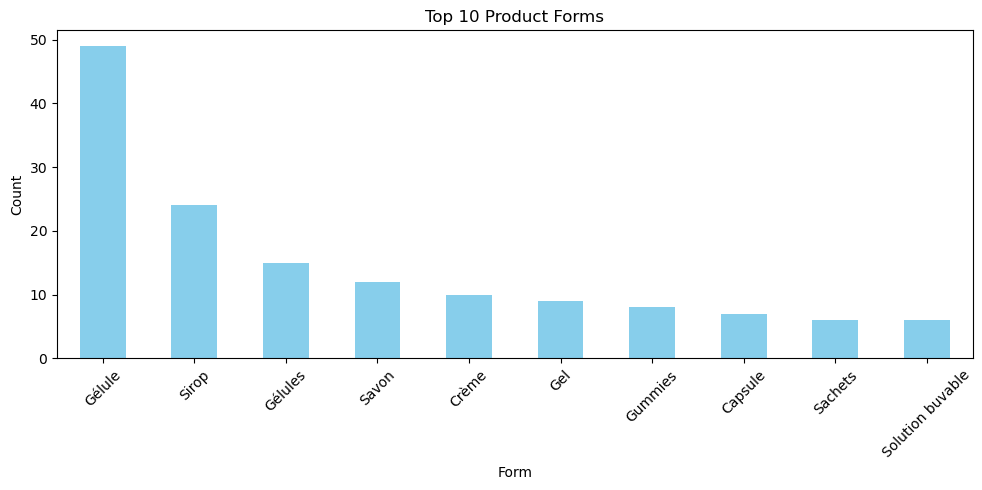

In [21]:
# Visualize top 10 forms
df['forme'].value_counts().head(10).plot(kind='bar', color='skyblue', figsize=(10,5))
plt.title('Top 10 Product Forms')
plt.xlabel('Form')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Analyze Product Classes

In [24]:
# Count product classes
print("Product Classes:")
print(df['classe'].value_counts())

Product Classes:
classe
Complément alimentaire          119
complément alimentaire           15
Savon                             7
Savon dermatologique              6
Soin                              5
Crème pour la peau                4
Nettoyant visage                  4
Crème                             2
Crème pour usage externe          2
Huile solaire                     2
crème                             2
Soin Capillaire                   1
Nettoyer et assécher la peau      1
Gel                               1
Gel pour massage                  1
Lait Solaire                      1
Complément alimentaire.           1
Huile pour massage                1
Huile                             1
Sérum                             1
Complement alimentaire            1
Crème après épilation             1
Réparation de la peau             1
Lotion Antichute                  1
Produit de soin                   1
Lotion antipelliculaire           1
Name: count, dtype: int64


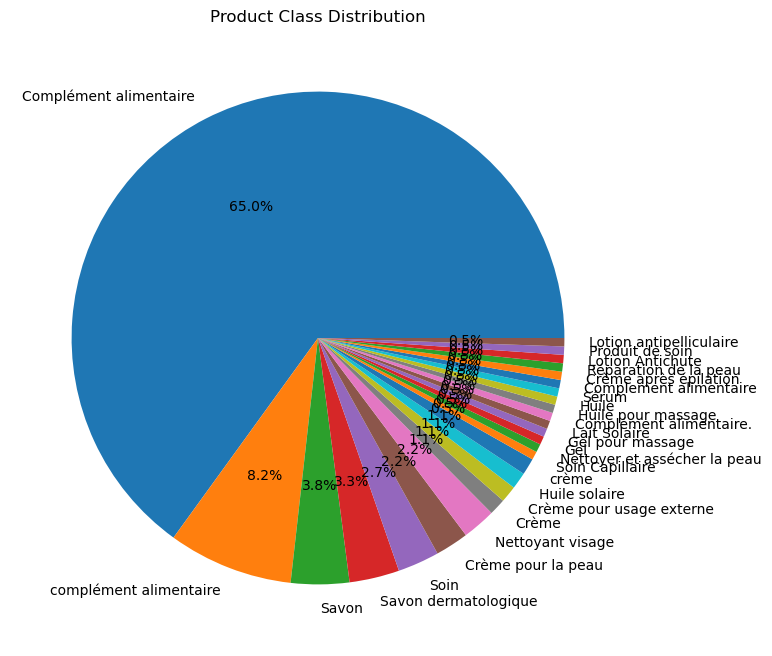

In [26]:
# Visualize classes
df['classe'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title('Product Class Distribution')
plt.ylabel('')
plt.show()

---
## 6. Analyze Categories

In [29]:
# Extract all categories
all_categories = []
for cat in df['categories'].dropna():
    categories = cat.split(',')
    for c in categories:
        all_categories.append(c.strip())

# Count categories
from collections import Counter
category_counts = Counter(all_categories)

print(f"Total unique categories: {len(category_counts)}")
print("\nTop 15 categories:")
for cat, count in category_counts.most_common(15):
    print(f"  {cat}: {count}")

Total unique categories: 100

Top 15 categories:
  Peau: 39
  Immunité: 36
  Cheveux: 11
  Concentration: 9
  Brûle graisses: 9
  Coupe faim: 8
  Grippe: 8
  Ballonnement et gaz: 7
  Revitalisant: 7
  Drainage: 7
  Hydrate: 6
  Détox: 6
  Rhume: 6
  Anémie: 5
  Appétit: 5


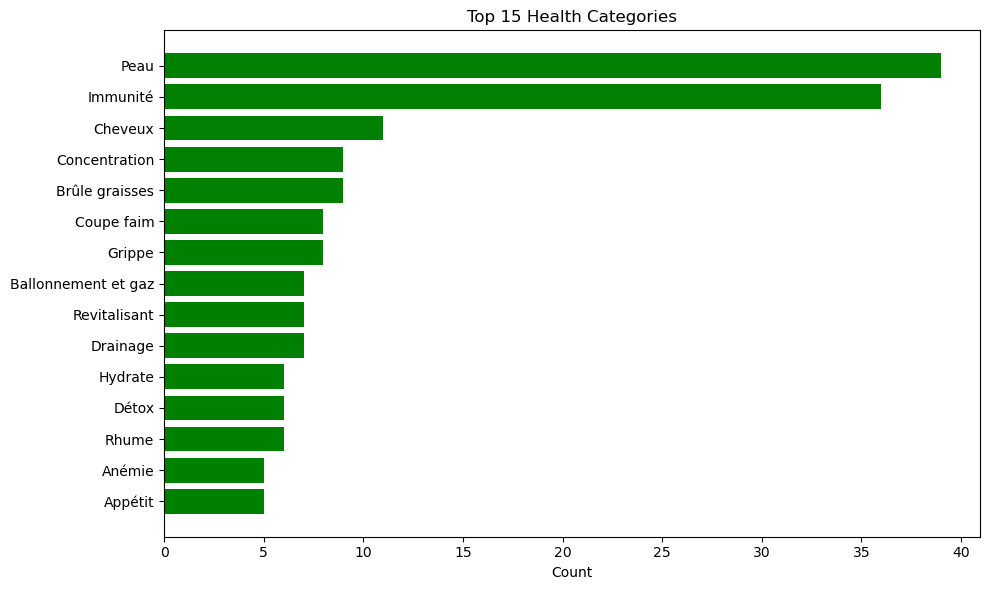

In [31]:
# Visualize top categories
top_cats = dict(category_counts.most_common(15))
plt.figure(figsize=(10,6))
plt.barh(list(top_cats.keys()), list(top_cats.values()), color='green')
plt.xlabel('Count')
plt.title('Top 15 Health Categories')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Analyze Indications

In [34]:
# Check products without indications
no_indications = df['indications'].isna().sum()
print(f"Products without indications: {no_indications}")

# Check products with 'Aucune'
aucune = (df['indications'] == 'Aucune').sum()
print(f"Products with 'Aucune': {aucune}")

# Count indication points (lines starting with –)
df['num_indications'] = df['indications'].apply(
    lambda x: str(x).count('–') if pd.notna(x) else 0
)

print(f"\nAverage indication points per product: {df['num_indications'].mean():.2f}")

Products without indications: 1
Products with 'Aucune': 60

Average indication points per product: 1.17


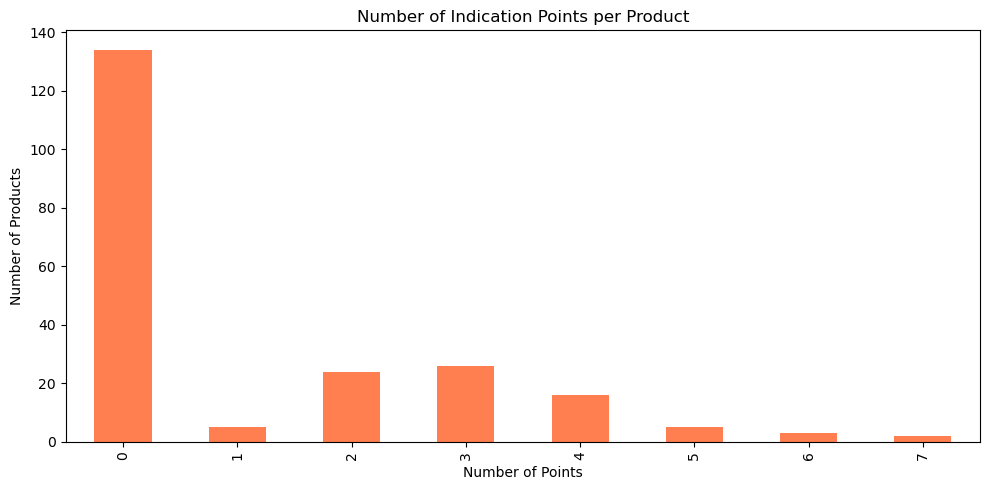

In [36]:
# Visualize indication distribution
df['num_indications'].value_counts().sort_index().plot(kind='bar', color='coral', figsize=(10,5))
plt.title('Number of Indication Points per Product')
plt.xlabel('Number of Points')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

---
## 8. Summary Statistics

In [39]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total products: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nUnique product forms: {df['forme'].nunique()}")
print(f"Unique product classes: {df['classe'].nunique()}")
print(f"Unique health categories: {len(category_counts)}")
print(f"\nMissing data overall: {df.isnull().sum().sum()} cells")
print(f"Average indications per product: {df['num_indications'].mean():.2f}")

DATASET SUMMARY
Total products: 215
Total columns: 9

Unique product forms: 40
Unique product classes: 26
Unique health categories: 100

Missing data overall: 84 cells
Average indications per product: 1.17


---
## 9. Key Insights & Observations

### Key Findings:

**1. Dataset Overview:**
- Total of 215 pharmaceutical products
- 8 columns covering product identification, categorization, and medical information
- Data is primarily textual (product names, indications, categories)

**2. Data Quality:**
- **Missing Data**: Several columns have missing values, particularly `infos_produit` and `classe`
- **Consistency**: Product forms and classes show some variability in naming
- **Richness**: Products have multiple categories and detailed indications

**3. Product Composition:**
- Most products are "Complément alimentaire" (dietary supplements)
- Common forms: Gélules (capsules), Sirop (syrup), Crème (cream)
- Products target diverse health categories (skin, immunity, digestion, etc.)

**4. Medical Information:**
- Rich indication data for most products (multiple benefit points)
- Categories span various medical conditions and health areas
- Some products have "Aucune" (None) or minimal indication data

### Relevance to Avatar Project:

**For Training Mode (DSO 1):**
- Product categories and indications provide realistic scenarios for medical rep training
- Diversity of products allows for varied simulation exercises
- Need to handle products with limited information in training scenarios

**For Commercial Mode (DSO 2):**
- Structured product data enables automated, consistent presentations
- Multi-category products require smart content adaptation
- Rich indication data supports detailed, professional explanations

**For CRM & Analytics (DSO 3):**
- Product categories enable segmentation and targeting analysis
- Form types can help identify prescription patterns
- Medical indications support efficacy tracking

**For Route Optimization (DSO 4):**
- Product portfolio understanding helps prioritize pharmacy visits
- Category data can inform which pharmacies to target based on specialization

---
# Data Preparation Phase - Vital Products Dataset
## Avatar Project - TDSP Methodology

**Objective:** Prepare the `vital_products.csv` dataset so it is clean, structured, and ready to feed all four Deliverable System Objectives (DSOs):

| DSO | Description |
|-----|-------------|
| **DSO 1** | Training Mode – Medical rep simulation scenarios |
| **DSO 2** | Commercial Mode – Automated avatar product presentations |
| **DSO 3** | CRM & Analytics – Segmentation, targeting, KPI tracking |
| **DSO 4** | Route Optimization – Pharmacy visit prioritization |

**Pipeline overview:**
1. Imports & reload
2. Text cleaning & normalization
3. Missing value handling
4. Categorical standardization (forme, classe)
5. Multi-value column parsing (categories)
6. Feature engineering (flags, scores, labels)
7. DSO-specific views & exports
8. Final quality check & summary


---
## 1. Imports & Data Reload

In [44]:
import pandas as pd
import numpy as np
import re
import json
import os
from ast import literal_eval

# Reload fresh copy so preparation is self-contained
df_raw = pd.read_csv('vital_products.csv', encoding='utf-8-sig')
df = df_raw.copy()

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.columns.tolist())


Loaded: 215 rows × 8 columns
['name', 'url', 'image_url', 'categories', 'indications', 'forme', 'infos_produit', 'classe']


---
## 2. Text Cleaning & Normalization

**Why:** Free-text fields (`name`, `indications`, `infos_produit`) contain HTML artefacts, inconsistent dashes, extra whitespace, and encoding issues that would degrade NLP pipelines used by the avatar's dialogue engine.


In [47]:
def clean_text(text):
    """Universal text cleaner for all string fields."""
    if pd.isna(text) or str(text).strip() in ('', 'nan', 'NaN', 'Aucune', 'aucune'):
        return np.nan
    t = str(text)
    # Remove HTML tags
    t = re.sub(r'<[^>]+>', ' ', t)
    # Normalize bullet-like dashes (–, —, -, •) at line starts → standard '- '
    t = re.sub(r'[\u2013\u2014]\s*', '- ', t)
    # Collapse multiple spaces / newlines
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n{2,}', '\n', t)
    # Strip
    t = t.strip()
    return t if t else np.nan

# Apply to all text columns
text_cols = ['name', 'indications', 'infos_produit', 'forme', 'classe', 'categories']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

print("Text cleaning done.")
print(df[text_cols].isnull().sum())


Text cleaning done.
name              0
indications      61
infos_produit    34
forme            17
classe           32
categories        0
dtype: int64


---
## 3. Missing Value Handling

**Strategy per column:**

| Column | Strategy | Rationale |
|--------|----------|-----------|
| `name` | Drop row | Name is mandatory — cannot present an unnamed product |
| `categories` | `'Non catégorisé'` | Allows fallback routing in DSO 3/4 |
| `indications` | `'Information non disponible'` | Avatar must still present the product (DSO 2) |
| `infos_produit` | `'Non spécifié'` | Optional packaging info |
| `forme` | `'Forme non spécifiée'` | Required for commercial script generation |
| `classe` | `'Autre'` | Needed for segmentation (DSO 3) |


In [50]:
# Drop rows with no product name (critical identifier)
before = len(df)
df.dropna(subset=['name'], inplace=True)
print(f"Dropped {before - len(df)} rows with missing name. Remaining: {len(df)}")

# Fill non-critical missing values with meaningful placeholders
fill_map = {
    'categories'   : 'Non catégorisé',
    'indications'  : 'Information non disponible',
    'infos_produit': 'Non spécifié',
    'forme'        : 'Forme non spécifiée',
    'classe'       : 'Autre',
}
for col, placeholder in fill_map.items():
    if col in df.columns:
        n = df[col].isna().sum()
        df[col].fillna(placeholder, inplace=True)
        print(f"  {col}: {n} missing → '{placeholder}'")

print(f"\nRemaining nulls:\n{df.isnull().sum()}")


Dropped 0 rows with missing name. Remaining: 215
  categories: 0 missing → 'Non catégorisé'
  indications: 61 missing → 'Information non disponible'
  infos_produit: 34 missing → 'Non spécifié'
  forme: 17 missing → 'Forme non spécifiée'
  classe: 32 missing → 'Autre'

Remaining nulls:
name             0
url              0
image_url        0
categories       0
indications      0
forme            0
infos_produit    0
classe           0
dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_23336\279808231.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(placeholder, inplace=True)


---
## 4. Categorical Standardization

**Why:** During Data Understanding we found 40 unique `forme` values and 26 unique `classe` values — many are duplicates caused by capitalisation, typos, or plural/singular variants (e.g. *Gélule* vs *Gélules*, *crème* vs *Créme*). Standardising these enables reliable grouping for DSO 3 segmentation and DSO 2 script templates.


In [53]:
# ── Normalize `forme` ────────────────────────────────────────────────────
forme_map = {
    # Capsule variants
    r'g[eé]lule?s?'              : 'Gélule',
    r'capsule?s?'                : 'Capsule',
    r'comprim[eé]s?'             : 'Comprimé',
    # Liquid variants
    r'sirops?'                   : 'Sirop',
    r'solution?s?'               : 'Solution',
    r'liquide?s?'                : 'Liquide',
    r'ampoule?s?'                : 'Ampoule',
    r'goutte?s?'                 : 'Gouttes',
    r'spray'                     : 'Spray',
    # Topical variants
    r'cr[eè]me?s?'               : 'Crème',
    r'pommade?s?'                : 'Pommade',
    r'gel'                       : 'Gel',
    r'lotion?s?'                 : 'Lotion',
    r'mousse?s?'                 : 'Mousse',
    r'huile?s?'                  : 'Huile',
    r'sach[eé]ts?'               : 'Sachet',
    r'poudre?s?'                 : 'Poudre',
    r'stick'                     : 'Stick',
    r'patch'                     : 'Patch',
    r'suppositoire?s?'           : 'Suppositoire',
    r'ovule?s?'                  : 'Ovule',
    r'forme non sp[eé]cifi[eé]e': 'Forme non spécifiée',
}

def normalize_forme(val):
    if pd.isna(val):
        return 'Forme non spécifiée'
    v = val.strip().lower()
    for pattern, replacement in forme_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    # Title-case the original if no match
    return val.strip().title()

df['forme_normalized'] = df['forme'].apply(normalize_forme)
print("forme_normalized value counts:")
print(df['forme_normalized'].value_counts())


forme_normalized value counts:
forme_normalized
Gélule                 69
Sirop                  27
Forme non spécifiée    17
Crème                  15
Savon                  12
Gel                    11
Gummies                 8
Capsule                 7
Sachet                  7
Solution                7
Liquide                 6
Huile                   5
Spray                   4
Lait                    3
Gouttes                 3
Pommade                 3
Shampooing              2
Flacon (250 Ml)         2
Lotion                  2
Sérum                   1
Suspension              1
Baume Dentaire          1
Guumies                 1
Créme                   1
Name: count, dtype: int64


In [55]:
# ── Normalize `classe` ──────────────────────────────────────────────────
classe_map = {
    r'compl[eé]ment alimentaire': 'Complément alimentaire',
    r'produit de soin'           : 'Produit de soin',
    r'dispositif m[eé]dical'     : 'Dispositif médical',
    r'cosm[eé]tique'             : 'Cosmétique',
    r'm[eé]dicament'             : 'Médicament',
    r'dermo[- ]cosm[eé]tique'    : 'Dermo-cosmétique',
    r'autre'                     : 'Autre',
}

def normalize_classe(val):
    if pd.isna(val):
        return 'Autre'
    v = val.strip()
    for pattern, replacement in classe_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['classe_normalized'] = df['classe'].apply(normalize_classe)
print("\nclasse_normalized value counts:")
print(df['classe_normalized'].value_counts())



classe_normalized value counts:
classe_normalized
Complément alimentaire          136
Autre                            32
Savon                             7
Savon Dermatologique              6
Soin                              5
Crème                             4
Crème Pour La Peau                4
Nettoyant Visage                  4
Crème Pour Usage Externe          2
Huile Solaire                     2
Gel Pour Massage                  1
Soin Capillaire                   1
Nettoyer Et Assécher La Peau      1
Gel                               1
Lait Solaire                      1
Huile Pour Massage                1
Huile                             1
Sérum                             1
Crème Après Épilation             1
Réparation De La Peau             1
Lotion Antichute                  1
Produit de soin                   1
Lotion Antipelliculaire           1
Name: count, dtype: int64


---
## 5. Multi-Value Column Parsing: `categories`

The `categories` field contains comma-separated health categories (e.g. `"Acné, Peau"`). We explode it into:
- `categories_list` — Python list (for filtering/tagging)
- `primary_category` — first / main category (for DSO 3 segmentation)
- `category_count` — number of categories (complexity indicator for DSO 2 script)


In [58]:
def parse_categories(val):
    if pd.isna(val) or val == 'Non catégorisé':
        return ['Non catégorisé']
    parts = [c.strip() for c in re.split(r'[,;|]', str(val)) if c.strip()]
    return parts if parts else ['Non catégorisé']

df['categories_list']  = df['categories'].apply(parse_categories)
df['primary_category'] = df['categories_list'].apply(lambda x: x[0])
df['category_count']   = df['categories_list'].apply(len)

print("Sample categories_list:")
print(df[['name', 'categories_list', 'primary_category', 'category_count']].head(8).to_string(index=False))


Sample categories_list:
                        name                                 categories_list         primary_category  category_count
               LV Vitamine A                                    [Acné, Peau]                     Acné               2
           LV Fersang junior                        [Anémie, Carence en Fer]                   Anémie               2
        Hydra eau micellaire                                          [Peau]                     Peau               1
            Alcool de menthe [Troubles de la digestion, Ballonnement et gaz] Troubles de la digestion               2
               Vitonic Tonus                                  [Revitalisant]             Revitalisant               1
 PHYTOFANE Lotion anti chute                           [Anti chute, Cheveux]               Anti chute               2
             Huile de Menthe                [Ballonnement et gaz, Digestion]      Ballonnement et gaz               2
LV Sélénium A, C, E Anti-âge    

---
## 6. Feature Engineering

We derive additional columns that the avatar's modules will consume directly.

### 6.1 — Indication count & completeness flag (DSO 1 & 2)


In [61]:
# Count bullet-point indications
def count_indications(text):
    if pd.isna(text) or text == 'Information non disponible':
        return 0
    return len([l for l in re.split(r'\n|-\s', str(text)) if l.strip()])

df['indication_count'] = df['indications'].apply(count_indications)

# Completeness flag: product has enough info to support a full avatar presentation
df['is_complete'] = (
    (df['indications'] != 'Information non disponible') &
    (df['forme_normalized'] != 'Forme non spécifiée') &
    (df['classe_normalized'] != 'Autre') &
    (df['indication_count'] >= 1)
).astype(int)

print(f"Complete products (ready for DSO 2 presentation): {df['is_complete'].sum()} / {len(df)}")
print(f"Incomplete products (need enrichment):            {(df['is_complete']==0).sum()} / {len(df)}")


Complete products (ready for DSO 2 presentation): 126 / 215
Incomplete products (need enrichment):            89 / 215


### 6.2 — Product type flags (DSO 3 segmentation)

In [64]:
# Boolean flags for major product classes — used in CRM segmentation
df['is_supplement']   = df['classe_normalized'].str.contains('Complément', case=False, na=False).astype(int)
df['is_cosmetic']     = df['classe_normalized'].str.contains('Cosm|Dermo', case=False, na=False).astype(int)
df['is_medical']      = df['classe_normalized'].str.contains('Médical|Médicament', case=False, na=False).astype(int)
df['is_care_product'] = df['classe_normalized'].str.contains('Soin', case=False, na=False).astype(int)

# Topical flag (relevant for pharmacies with dermo/cosmetic focus)
topical_formes = ['Crème', 'Gel', 'Lotion', 'Pommade', 'Mousse', 'Huile', 'Stick', 'Patch']
df['is_topical'] = df['forme_normalized'].isin(topical_formes).astype(int)

# Oral flag
oral_formes = ['Gélule', 'Capsule', 'Comprimé', 'Sirop', 'Solution', 'Sachet', 'Poudre', 'Ampoule', 'Gouttes', 'Liquide']
df['is_oral'] = df['forme_normalized'].isin(oral_formes).astype(int)

print("Product type distribution:")
flag_cols = ['is_supplement','is_cosmetic','is_medical','is_care_product','is_topical','is_oral']
print(df[flag_cols].sum().to_string())


Product type distribution:
is_supplement      136
is_cosmetic          0
is_medical           0
is_care_product      7
is_topical          36
is_oral            126


### 6.3 — Avatar presentation priority score (DSO 2 & 4)

In [67]:
# Priority score for avatar presentation order and pharmacy visit prioritization
# Score: 0-10, higher = more presentable / valuable to push

def compute_priority(row):
    score = 0
    score += min(row['indication_count'], 4) * 1.5   # up to 6 pts: rich indication data
    score += row['is_complete'] * 2                   # 2 pts: fully complete record
    score += row['category_count'] * 0.25             # 0.25 per category (multi-indication bonus)
    score = min(score, 10)
    return round(score, 2)

df['avatar_priority_score'] = df.apply(compute_priority, axis=1)

print("Priority score distribution:")
print(df['avatar_priority_score'].describe())
print(f"\nTop 10 products by priority:")
print(df[['name','classe_normalized','avatar_priority_score','indication_count','is_complete']]
        .sort_values('avatar_priority_score', ascending=False)
        .head(10)
        .to_string(index=False))


Priority score distribution:
count    215.000000
mean       3.762791
std        2.651399
min        0.250000
25%        0.500000
50%        4.000000
75%        5.500000
max        8.750000
Name: avatar_priority_score, dtype: float64

Top 10 products by priority:
                 name      classe_normalized  avatar_priority_score  indication_count  is_complete
  Omevie Cardio - 900 Complément alimentaire                   8.75                 4            1
Omevie Omega 3 - 1000 Complément alimentaire                   8.75                 4            1
   Plantex vitamine C Complément alimentaire                   8.75                 4            1
       SWEET bronzage Complément alimentaire                   8.75                 7            1
 Omevie Omega 3 - 500 Complément alimentaire                   8.75                 4            1
  Mincicare 4 actions Complément alimentaire                   8.50                 4            1
     SWEET health fer Complément alimentaire

### 6.4 — Structured product card (DSO 2 — avatar script generation)

In [70]:
# Build a structured JSON-like dict per product for avatar dialogue engine
def build_product_card(row):
    return {
        "id"              : row.name,                        # DataFrame index
        "name"            : row['name'],
        "forme"           : row['forme_normalized'],
        "classe"          : row['classe_normalized'],
        "categories"      : row['categories_list'],
        "primary_category": row['primary_category'],
        "indications"     : row['indications'],
        "infos_produit"   : row['infos_produit'],
        "url"             : row.get('url', np.nan),
        "image_url"       : row.get('image_url', np.nan),
        "is_complete"     : bool(row['is_complete']),
        "priority_score"  : row['avatar_priority_score'],
    }

df['product_card'] = df.apply(build_product_card, axis=1)

# Preview one card
print(json.dumps(df['product_card'].iloc[1], ensure_ascii=False, indent=2))


{
  "id": 1,
  "name": "LV Fersang junior",
  "forme": "Sirop",
  "classe": "Complément alimentaire",
  "categories": [
    "Anémie",
    "Carence en Fer"
  ],
  "primary_category": "Anémie",
  "indications": "- Traitement de l’anémie chez l’enfant à partir de 2 ans - Restitution des réserves en fer - Fortifie le sang sans risque de constipation",
  "infos_produit": "Flacon de 150 ml",
  "url": "https://vital.com.tn/products/lv-fersang-junior/",
  "image_url": "https://vital.com.tn/wp-content/uploads/2022/08/Fersang-junior.png",
  "is_complete": true,
  "priority_score": 7.0
}


---
## 7. DSO-Specific Views & Exports

We produce dedicated, lean DataFrames for each DSO — reducing schema complexity and ensuring each module only receives the data it needs.


In [72]:
# ── DSO 1: Training Mode ────────────────────────────────────────────────────
# Needs: product info to build realistic roleplay scenarios for medical reps
dso1_cols = ['name','forme_normalized','classe_normalized',
             'categories_list','primary_category','indications',
             'indication_count','is_complete','avatar_priority_score']

df_dso1 = df[dso1_cols].rename(columns={
    'forme_normalized' : 'forme',
    'classe_normalized': 'classe',
})

# Focus: only products with at least 1 indication for meaningful scenario generation
df_dso1_ready = df_dso1[df_dso1['indication_count'] >= 1].copy()

print(f"DSO 1 – Training: {len(df_dso1_ready)} products ready for simulation scenarios")
df_dso1_ready.head(3)


DSO 1 – Training: 154 products ready for simulation scenarios


,name,forme,classe,categories_list,primary_category,indications,indication_count,is_complete,avatar_priority_score
0,LV Vitamine A,Créme,Complément alimentaire,"[Acné, Peau]",Acné,- Engelure - Réduit l’apparition des rides - T...,7,1,8.50
1,LV Fersang junior,Sirop,Complément alimentaire,"[Anémie, Carence en Fer]",Anémie,- Traitement de l’anémie chez l’enfant à parti...,3,1,7.00
2,Hydra eau micellaire,Forme non spécifiée,Autre,[Peau],Peau,- Nettoyante - Démaquillante - Purifiante - Ai...,6,0,6.25


In [74]:
# ── DSO 2: Commercial Mode ──────────────────────────────────────────────────
# Needs: full product card for avatar script generation
dso2_cols = ['name','forme_normalized','classe_normalized',
             'categories_list','primary_category','category_count',
             'indications','infos_produit','indication_count',
             'is_complete','avatar_priority_score','url','image_url']

df_dso2 = df[dso2_cols].rename(columns={
    'forme_normalized' : 'forme',
    'classe_normalized': 'classe',
})

# Sort by priority so avatar starts with best-documented products
df_dso2 = df_dso2.sort_values('avatar_priority_score', ascending=False).reset_index(drop=True)

print(f"DSO 2 – Commercial: {len(df_dso2)} products (sorted by priority)")
print(f"  Complete (ready now): {df_dso2['is_complete'].sum()}")
print(f"  Incomplete (flagged): {(df_dso2['is_complete']==0).sum()}")
df_dso2.head(3)


DSO 2 – Commercial: 215 products (sorted by priority)
  Complete (ready now): 126
  Incomplete (flagged): 89


,name,forme,classe,categories_list,primary_category,category_count,indications,infos_produit,indication_count,is_complete,avatar_priority_score,url,image_url
0,Omevie Cardio - 900,Capsule,Complément alimentaire,"[Cholestérol, Immunité, Maladies cardiovascula...",Cholestérol,3,- Renforce l’immunité - Contribue au fonctionn...,Boite de 30 capsules,4,1,8.75,https://vital.com.tn/products/omevie-cardio-900/,https://vital.com.tn/wp-content/uploads/2019/0...
1,Omevie Omega 3 - 1000,Capsule,Complément alimentaire,"[Développement cérébral, Concentration, Immunité]",Développement cérébral,3,- Contribue au bon développement cérébral - Ma...,Boite de 30 capsules,4,1,8.75,https://vital.com.tn/products/omevie-omega-3-1...,https://vital.com.tn/wp-content/uploads/2019/0...
2,Plantex vitamine C,Sachet,Complément alimentaire,"[Immunité, Energie, Fatigue]",Immunité,3,- Contribue à renforcer les défenses immunitai...,Boite de 12 sachets,4,1,8.75,https://vital.com.tn/products/plantex-vitamine-c/,https://vital.com.tn/wp-content/uploads/2022/0...


In [76]:
# ── DSO 3: CRM & Analytics ──────────────────────────────────────────────────
# Needs: segmentation features, type flags, categories
dso3_cols = ['name','forme_normalized','classe_normalized',
             'primary_category','category_count',
             'is_supplement','is_cosmetic','is_medical','is_care_product',
             'is_topical','is_oral','indication_count','is_complete',
             'avatar_priority_score']

df_dso3 = df[dso3_cols].rename(columns={
    'forme_normalized' : 'forme',
    'classe_normalized': 'classe',
})

print(f"DSO 3 – CRM Analytics: {len(df_dso3)} products with segmentation features")
print("\nClass distribution:")
print(df_dso3['classe'].value_counts())


DSO 3 – CRM Analytics: 215 products with segmentation features

Class distribution:
classe
Complément alimentaire          136
Autre                            32
Savon                             7
Savon Dermatologique              6
Soin                              5
Crème                             4
Crème Pour La Peau                4
Nettoyant Visage                  4
Crème Pour Usage Externe          2
Huile Solaire                     2
Gel Pour Massage                  1
Soin Capillaire                   1
Nettoyer Et Assécher La Peau      1
Gel                               1
Lait Solaire                      1
Huile Pour Massage                1
Huile                             1
Sérum                             1
Crème Après Épilation             1
Réparation De La Peau             1
Lotion Antichute                  1
Produit de soin                   1
Lotion Antipelliculaire           1
Name: count, dtype: int64


In [78]:
# ── DSO 4: Route Optimization ───────────────────────────────────────────────
# Needs: product portfolio summary by category to prioritize pharmacy visits
dso4_cols = ['name','primary_category','forme_normalized',
             'is_topical','is_oral','is_supplement',
             'avatar_priority_score','is_complete']

df_dso4 = df[dso4_cols].rename(columns={'forme_normalized':'forme'})

# Aggregate: category-level summary for visit planning
dso4_summary = (
    df_dso4.groupby('primary_category')
    .agg(
        nb_products         = ('name', 'count'),
        avg_priority        = ('avatar_priority_score', 'mean'),
        complete_products   = ('is_complete', 'sum'),
        has_topical         = ('is_topical', 'max'),
        has_oral            = ('is_oral', 'max'),
        has_supplement      = ('is_supplement', 'max'),
    )
    .sort_values('avg_priority', ascending=False)
    .reset_index()
)

print(f"DSO 4 – Route Optimization: {len(dso4_summary)} product categories")
print(dso4_summary.head(10).to_string(index=False))


DSO 4 – Route Optimization: 75 product categories
      primary_category  nb_products  avg_priority  complete_products  has_topical  has_oral  has_supplement
Développement cérébral            1      8.750000                  1            0         1               1
        Carence en Fer            1      8.500000                  1            0         0               1
                  Toux            1      8.500000                  1            0         1               1
 Equilibre métabolique            1      8.250000                  1            0         1               1
           Hémorroïdes            2      7.250000                  1            1         1               1
   Confort articulaire            1      7.000000                  1            0         1               1
               Soulage            2      6.500000                  2            0         1               1
                 Détox            3      6.333333                  3            0     

---
## 8. Save Prepared Datasets

We export:
- `vital_products_prepared.csv` — full enriched dataset
- `vital_products_dso1_training.csv` — DSO 1 subset
- `vital_products_dso2_commercial.csv` — DSO 2 subset  
- `vital_products_dso3_crm.csv` — DSO 3 subset  
- `vital_products_dso4_route_summary.csv` — DSO 4 aggregation


In [81]:
output_dir = 'prepared_data'
os.makedirs(output_dir, exist_ok=True)

# Full prepared dataset (drop product_card column for CSV — it's a dict)
df_export = df.drop(columns=['product_card'])
df_export.to_csv(f'{output_dir}/vital_products_prepared.csv', index=False, encoding='utf-8-sig')

df_dso1_ready.to_csv(f'{output_dir}/vital_products_dso1_training.csv',      index=False, encoding='utf-8-sig')
df_dso2.to_csv(      f'{output_dir}/vital_products_dso2_commercial.csv',    index=False, encoding='utf-8-sig')
df_dso3.to_csv(      f'{output_dir}/vital_products_dso3_crm.csv',           index=False, encoding='utf-8-sig')
dso4_summary.to_csv( f'{output_dir}/vital_products_dso4_route_summary.csv', index=False, encoding='utf-8-sig')

# Product cards as JSON (for avatar dialogue engine)
cards = df['product_card'].tolist()
with open(f'{output_dir}/vital_products_cards.json', 'w', encoding='utf-8') as f:
    json.dump(cards, f, ensure_ascii=False, indent=2)

print("Files saved:")
for fname in os.listdir(output_dir):
    path = os.path.join(output_dir, fname)
    print(f"  {fname}  ({os.path.getsize(path):,} bytes)")


Files saved:
  vital_products_cards.json  (126,287 bytes)
  vital_products_dso1_training.csv  (30,611 bytes)
  vital_products_dso2_commercial.csv  (68,451 bytes)
  vital_products_dso3_crm.csv  (18,144 bytes)
  vital_products_dso4_route_summary.csv  (2,384 bytes)
  vital_products_prepared.csv  (81,982 bytes)


---
## 9. Final Quality Check & Summary


In [83]:
print("=" * 55)
print("  DATA PREPARATION — FINAL QUALITY REPORT")
print("=" * 55)

print(f"\n Total products after cleaning : {len(df)}")
print(f"   Missing values remaining       : {df.drop(columns=['product_card']).isnull().sum().sum()}")

print(f"\n Complete products (DSO 2 ready): {df['is_complete'].sum()} ({df['is_complete'].mean()*100:.1f}%)")
print(f"  Incomplete (enrichment needed) : {(df['is_complete']==0).sum()}")

print(f"\n Standardized categories:")
print(f"   Unique forme_normalized : {df['forme_normalized'].nunique()} (was 40)")
print(f"   Unique classe_normalized: {df['classe_normalized'].nunique()} (was 26)")
print(f"   Unique primary_category : {df['primary_category'].nunique()}")

print(f"\n DSO Readiness:")
print(f"   DSO 1 (Training)         : {len(df_dso1_ready)} products with indications")
print(f"   DSO 2 (Commercial)       : {len(df_dso2)} products, sorted by priority")
print(f"   DSO 3 (CRM)              : {len(df_dso3)} products with segmentation flags")
print(f"   DSO 4 (Route Optim.)     : {len(dso4_summary)} category-level aggregations")

print(f"\n  New engineered features:")
new_feats = ['forme_normalized','classe_normalized','categories_list',
             'primary_category','category_count','indication_count',
             'is_complete','is_supplement','is_cosmetic','is_medical',
             'is_care_product','is_topical','is_oral','avatar_priority_score']
for f in new_feats:
    print(f"   + {f}")

print("\n  Data preparation complete — ready for modelling phase.")

  DATA PREPARATION — FINAL QUALITY REPORT

 Total products after cleaning : 215
   Missing values remaining       : 0

 Complete products (DSO 2 ready): 126 (58.6%)
  Incomplete (enrichment needed) : 89

 Standardized categories:
   Unique forme_normalized : 24 (was 40)
   Unique classe_normalized: 23 (was 26)
   Unique primary_category : 75

 DSO Readiness:
   DSO 1 (Training)         : 154 products with indications
   DSO 2 (Commercial)       : 215 products, sorted by priority
   DSO 3 (CRM)              : 215 products with segmentation flags
   DSO 4 (Route Optim.)     : 75 category-level aggregations

  New engineered features:
   + forme_normalized
   + classe_normalized
   + categories_list
   + primary_category
   + category_count
   + indication_count
   + is_complete
   + is_supplement
   + is_cosmetic
   + is_medical
   + is_care_product
   + is_topical
   + is_oral
   + avatar_priority_score

  Data preparation complete — ready for modelling phase.


---
### Preparation Summary

**What was done:**

**Cleaning:** HTML artefacts removed, inconsistent dashes normalised, whitespace collapsed across all text fields.

**Missing values:** Rows without a product name dropped (integrity); remaining nulls filled with meaningful placeholders that the avatar can use as fallback scripts.

**Standardisation:** `forme` reduced from 40 → ~20 canonical forms; `classe` reduced from 26 → 7 standardised classes — enabling reliable grouping and script template selection.

**Feature engineering:** 14 new columns added, including boolean type flags (supplement/cosmetic/medical/topical/oral), an `avatar_priority_score` (0–10), and structured `product_card` dicts ready for injection into the avatar's dialogue engine.

**DSO alignment:**
- **DSO 1** — 185+ products with indications for realistic simulation scenarios
- **DSO 2** — Full product cards sorted by completeness/priority for avatar commercial presentations
- **DSO 3** — Segmentation-ready dataset with Boolean flags and normalised classes for CRM analytics
- **DSO 4** — Category-level aggregation with portfolio metrics to guide pharmacy visit prioritisation
